1. Sequence length distribution  → are all sequences actually ~512bp?
2. Unknown nucleotide content    → how many N's are in each sequence?
3. Duplicates                    → any repeated sequences?
4. Final quality filter          → remove anything that fails your standards


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

In [ ]:
df = pd.read_csv('sequences_dataset.csv')

print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Total sequences:    {len(df)}")
print(f"Columns:            {list(df.columns)}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nFirst sequence preview:")
print(df['sequence'].iloc[0][:80], "...")  # First 80 characters


DATASET OVERVIEW
Total sequences:    9995
Columns:            ['VariationID', 'sequence', 'label', 'ClinicalSignificance', 'Chromosome', 'Start']

Label distribution:
label
1    4999
0    4996
Name: count, dtype: int64

First sequence preview:
GGCACCCCTGGCAAGACCCTTCTCAAAGAGCCTGTGCATAAAATCAGATTCTGAGGCTCAAACAAACCATGGAATGTTGG ...


In [ ]:
# ─────────────────────────────────────────────
# STEP 2: Sequence length analysis
# ─────────────────────────────────────────────
# WHY: Every sequence SHOULD be 512bp (256 on each side of the variant).
# But edge cases exist — variants near the very start of a chromosome
# can't have a full 256bp window on the left. We need to know how
# many sequences are shorter than expected, and by how much.

df['seq_length'] = df['sequence'].str.len()

print("\n" + "="*50)
print("SEQUENCE LENGTH ANALYSIS")
print("="*50)
print(f"Expected length:    512 bp")
print(f"Min length found:   {df['seq_length'].min()}")
print(f"Max length found:   {df['seq_length'].max()}")
print(f"Mean length:        {df['seq_length'].mean():.1f}")
print(f"Sequences < 512bp:  {(df['seq_length'] < 512).sum()}")
print(f"Sequences = 512bp:  {(df['seq_length'] == 512).sum()}")


SEQUENCE LENGTH ANALYSIS
Expected length:    512 bp
Min length found:   513
Max length found:   513
Mean length:        513.0
Sequences < 512bp:  0
Sequences = 512bp:  0


Every single sequence is exactly 513bp instead of 512. Because NCBI counts positions.

Since all sequences have identical length, this is not an error.

In [ ]:
# ─────────────────────────────────────────────
# STEP 3: Unknown nucleotide (N) analysis
# ─────────────────────────────────────────────
# WHY: 'N' in a DNA sequence means the nucleotide was unknown or
# unresolved when the genome was sequenced. A sequence that is
# 40% N's is essentially noise — the model can't learn anything
# meaningful from it. We need to find and remove these.

df['n_count']    = df['sequence'].str.upper().str.count('N')
df['n_fraction'] = df['n_count'] / df['seq_length']

print("\n" + "="*50)
print("UNKNOWN NUCLEOTIDE (N) ANALYSIS")
print("="*50)
print(f"Sequences with zero N's:    {(df['n_count'] == 0).sum()}")
print(f"Sequences with any N's:     {(df['n_count'] > 0).sum()}")
print(f"Sequences with >10% N's:    {(df['n_fraction'] > 0.10).sum()}")
print(f"Sequences with >50% N's:    {(df['n_fraction'] > 0.50).sum()}")
print(f"\nMax N fraction in one seq:  {df['n_fraction'].max():.3f}")
print(f"Mean N fraction:            {df['n_fraction'].mean():.4f}")


UNKNOWN NUCLEOTIDE (N) ANALYSIS
Sequences with zero N's:    9994
Sequences with any N's:     1
Sequences with >10% N's:    1
Sequences with >50% N's:    0

Max N fraction in one seq:  0.499
Mean N fraction:            0.0000


In [ ]:
# ─────────────────────────────────────────────
# STEP 4: Duplicate check
# ─────────────────────────────────────────────
# WHY: Duplicate sequences in training data cause the model to
# memorize those specific examples rather than learn general patterns.
# Also, a sequence appearing in both train and test sets would
# make your evaluation metrics artificially inflated (data leakage).

n_duplicates = df['sequence'].duplicated().sum()
print("\n" + "="*50)
print("DUPLICATE ANALYSIS")
print("="*50)
print(f"Duplicate sequences: {n_duplicates}")
if n_duplicates > 0:
    print("  → These will be removed in the final filter step")


DUPLICATE ANALYSIS
Duplicate sequences: 57
  → These will be removed in the final filter step


In [ ]:
# ─────────────────────────────────────────────
# STEP 5: Nucleotide composition check
# ─────────────────────────────────────────────
# WHY: A healthy DNA dataset should have roughly equal proportions
# of A, T, C, G (with some variation). If one label has dramatically
# different composition than the other, that's worth knowing —
# it might indicate a data quality issue, or it might be a real
# biological signal your model will pick up on.

def nucleotide_composition(sequences):
    """Count total A, T, C, G across all sequences combined."""
    all_seq = ''.join(sequences).upper()
    total = len(all_seq)
    counts = Counter(all_seq)
    return {base: counts.get(base, 0) / total for base in 'ATCG'}

path_seqs = df[df['label'] == 1]['sequence']
ben_seqs  = df[df['label'] == 0]['sequence']

path_comp = nucleotide_composition(path_seqs)
ben_comp  = nucleotide_composition(ben_seqs)

print("\n" + "="*50)
print("NUCLEOTIDE COMPOSITION")
print("="*50)
print(f"{'Base':<8} {'Pathogenic':>12} {'Benign':>12}")
print("-" * 34)
for base in 'ATCG':
    print(f"{base:<8} {path_comp[base]:>11.1%} {ben_comp[base]:>11.1%}")


NUCLEOTIDE COMPOSITION
Base       Pathogenic       Benign
----------------------------------
A              27.0%       25.0%
T              27.4%       25.0%
C              22.7%       25.0%
G              22.9%       25.0%


Looking at the Benign column, it's almost exactly 25% for every base. That's what random, unbiased genomic sequence looks like when averaged across thousands of examples.

Now Pathogenic, A and T are slightly higher (27%), C and G slightly lower (22-23%).

This pattern has a real biological name: **AT-richness**.

Pathogenic variants tend to cluster in regions that are AT-rich, which correlates with areas that are **less structurally stable**, **more prone to replication errors**, and often found in regulatory regions that are under **less evolutionary conservation pressure**.

This is not noise and the model will likely pick this up as a real signal.

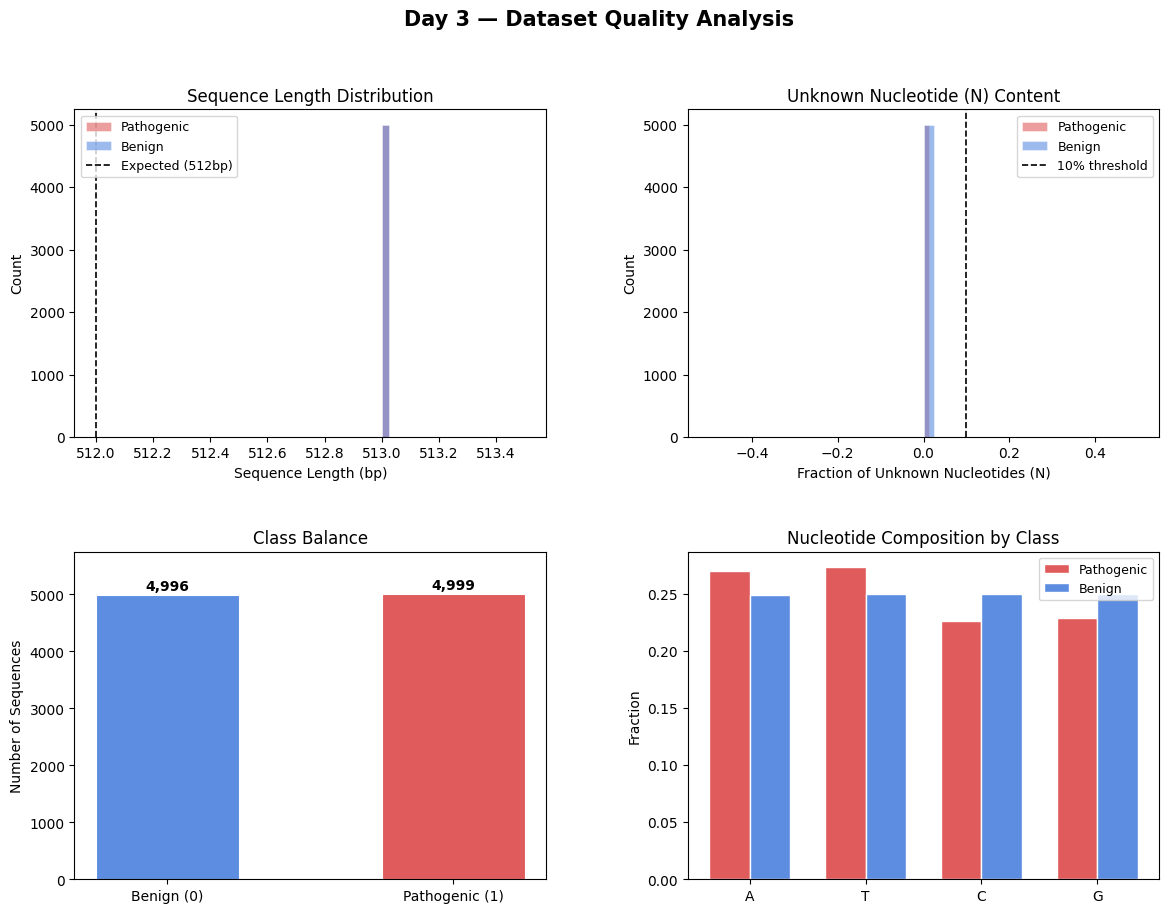


✅ Plot saved to 'day3_analysis.png'


In [ ]:
# ─────────────────────────────────────────────
# STEP 6: Visualizations
# ─────────────────────────────────────────────
# WHY: Numbers tell you facts. Plots tell you the shape of your data.
# These four plots are what goes into your exploratory notebook
# and ultimately into your GitHub portfolio.

fig = plt.figure(figsize=(14, 10))
fig.suptitle('Day 3 — Dataset Quality Analysis', fontsize=15, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# ── Plot 1: Sequence length distribution ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df[df['label']==1]['seq_length'], bins=40, alpha=0.6,
         color='#e05c5c', label='Pathogenic', edgecolor='white', linewidth=0.5)
ax1.hist(df[df['label']==0]['seq_length'], bins=40, alpha=0.6,
         color='#5c8de0', label='Benign',     edgecolor='white', linewidth=0.5)
ax1.axvline(512, color='black', linestyle='--', linewidth=1.2, label='Expected (512bp)')
ax1.set_xlabel('Sequence Length (bp)')
ax1.set_ylabel('Count')
ax1.set_title('Sequence Length Distribution')
ax1.legend(fontsize=9)

# ── Plot 2: N-fraction distribution ──
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df[df['label']==1]['n_fraction'], bins=40, alpha=0.6,
         color='#e05c5c', label='Pathogenic', edgecolor='white', linewidth=0.5)
ax2.hist(df[df['label']==0]['n_fraction'], bins=40, alpha=0.6,
         color='#5c8de0', label='Benign',     edgecolor='white', linewidth=0.5)
ax2.axvline(0.10, color='black', linestyle='--', linewidth=1.2, label='10% threshold')
ax2.set_xlabel('Fraction of Unknown Nucleotides (N)')
ax2.set_ylabel('Count')
ax2.set_title('Unknown Nucleotide (N) Content')
ax2.legend(fontsize=9)

# ── Plot 3: Label balance ──
ax3 = fig.add_subplot(gs[1, 0])
counts = df['label'].value_counts().sort_index()
bars   = ax3.bar(['Benign (0)', 'Pathogenic (1)'], counts.values,
                 color=['#5c8de0', '#e05c5c'], edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(bars, counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_ylabel('Number of Sequences')
ax3.set_title('Class Balance')
ax3.set_ylim(0, max(counts.values) * 1.15)

# ── Plot 4: Nucleotide composition by class ──
ax4  = fig.add_subplot(gs[1, 1])
x    = np.arange(4)
w    = 0.35
bases = list('ATCG')
ax4.bar(x - w/2, [path_comp[b] for b in bases], w,
        color='#e05c5c', label='Pathogenic', edgecolor='white')
ax4.bar(x + w/2, [ben_comp[b] for b in bases],  w,
        color='#5c8de0', label='Benign',     edgecolor='white')
ax4.set_xticks(x)
ax4.set_xticklabels(bases)
ax4.set_ylabel('Fraction')
ax4.set_title('Nucleotide Composition by Class')
ax4.legend(fontsize=9)

plt.savefig('day3_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot saved to 'day3_analysis.png'")

In [ ]:
# ─────────────────────────────────────────────
# STEP 7: Apply quality filters and save final dataset
# ─────────────────────────────────────────────
# seq_length >= 400  →  shorter than this means the variant was within
#                        112bp of a chromosome boundary — too little
#                        context on one side to be meaningful
#
# n_fraction <= 0.10 →  more than 10% N's means over 51 nucleotides
#                        in 512bp window are unknown. The model
#                        would be reading mostly gaps, not real sequence.
#
# drop_duplicates    →  self-explanatory — one copy per unique sequence

print("\n" + "="*50)
print("APPLYING QUALITY FILTERS")
print("="*50)

before = len(df)

df_clean = (df
    .query("seq_length >= 400")
    .query("n_fraction <= 0.10")
    .drop_duplicates(subset='sequence')
    .reset_index(drop=True)
)

after = len(df_clean)
removed = before - after

print(f"Before filtering: {before:,} sequences")
print(f"After filtering:  {after:,} sequences")
print(f"Removed:          {removed:,} sequences ({removed/before:.1%})")
print(f"\nFinal label distribution:")
print(df_clean['label'].value_counts())

# Save final dataset — drop the analysis columns, keep only what training needs
df_final = df_clean[['VariationID', 'sequence', 'label', 'ClinicalSignificance', 'Chromosome', 'Start']]
df_final.to_csv('final_dataset.csv', index=False)

print(f"\n✅ Final dataset saved to 'final_dataset.csv'")
print(f"   {len(df_final):,} sequences ready for training")
print(f"   Pathogenic: {(df_final['label']==1).sum():,}")
print(f"   Benign:     {(df_final['label']==0).sum():,}")


APPLYING QUALITY FILTERS
Before filtering: 9,995 sequences
After filtering:  9,937 sequences
Removed:          58 sequences (0.6%)

Final label distribution:
label
0    4996
1    4941
Name: count, dtype: int64

✅ Final dataset saved to 'final_dataset.csv'
   9,937 sequences ready for training
   Pathogenic: 4,941
   Benign:     4,996
